# NB04h — HMP_2019_ibdmdb External Replication

**Project**: `ibd_phage_targeting` — Pillar 1 + Pillar 2 external replication
**Depends on**: NB01b (K=4 consensus ecotype assignments), NB04e (E1 Tier-A)

## Purpose

External replication of the K=4 ecotype framework on an independent IBD cohort — **HMP_2019_ibdmdb** (HMP2 / IBDMDB), pulled directly from `curatedMetagenomicData` v3.18 via the companion R script `pull_hmp2_metaphlan3.R`. HMP2 is explicitly NOT in the `CMD_IBD` cohort ingestion that trained our ecotype framework (cMD's `HMP_2019_ibdmdb` was absent from our mart's CMD_IBD substudy list), so it is a genuinely held-out cohort.

HMP2 at cMD 3.18:
- **1,627 samples** from **130 subjects**, heavily longitudinal (many subjects with 10-12 samples)
- **582 species-level MetaPhlAn3 rows** (587 taxonomic rows; we use species-level only)
- Disease breakdown: **748 CD, 453 UC, 426 nonIBD / control**
- Same MetaPhlAn3 pipeline as the cMD training data → same classifier namespace, no Kaiju↔MetaPhlAn3 asymmetry problem

## Tests

1. **Ecotype distribution χ²**: HMP2 samples projected onto K=4 LDA. Distribution should be non-uniform; CD should concentrate in E1/E3 per the cMD pattern.
2. **Disease-subtype stratification**: for each ecotype, what fraction is CD vs UC vs nonIBD?
3. **E1 Tier-A replication**: compute HMP2 CD-vs-nonIBD CLR-Δ per species within the HMP2-projected E1 samples; compare to NB04e E1 Tier-A top-20 list.
4. **Projection confidence**: per-sample max posterior (LDA γ) — high confidence = strong ecotype membership; low = sample is between ecotypes.

Because HMP2 is longitudinal, per-subject aggregation is used for the ecotype distribution test (subject-level, not sample-level, to avoid pseudo-replication).


In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import json
import numpy as np
import pandas as pd
from sklearn.decomposition import LatentDirichletAllocation
from scipy.optimize import linear_sum_assignment
from scipy.stats import chi2_contingency, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

DATA_MART = Path.home() / 'data' / 'CrohnsPhage'
EXT = Path.home() / 'data' / 'CrohnsPhage_ext'
DATA_OUT = Path('../data')
FIG_OUT = Path('../figures')
K_REF = 4
RANDOM_STATE = 42


## §1. Rebuild training wide matrix + refit reference LDA

In [2]:
# Same pipeline as NB04c / NB04f
syn = pd.read_csv(DATA_OUT / 'species_synonymy.tsv', sep='\t')
lookup = dict(zip(syn.alias, syn.canonical))

ta = pd.read_parquet(DATA_MART / 'fact_taxon_abundance.snappy.parquet')
ta = ta[(ta.classification_method == 'metaphlan3') & (ta.study_id.isin(['CMD_HEALTHY','CMD_IBD']))].copy()

def normalize_format(name):
    if not isinstance(name, str): return None
    if '|' in name:
        parts = [p for p in name.split('|') if p.startswith('s__')]
        return parts[0][3:].replace('_', ' ').strip() if parts else None
    return name.replace('[','').replace(']','').strip()

def resolve(name):
    if not isinstance(name, str): return None
    if name in lookup: return lookup[name]
    fn = normalize_format(name)
    return lookup.get(fn, fn) if fn else None

ta['species'] = ta['taxon_name_original'].map(resolve)
ta = ta.dropna(subset=['species']).copy()
wide = ta.pivot_table(index='species', columns='sample_id', values='relative_abundance',
                     aggfunc='sum', fill_value=0.0)

eco = pd.read_csv(DATA_OUT / 'ecotype_assignments.tsv', sep='\t')
eco_map = dict(zip(eco.sample_id, eco.consensus_ecotype))
diag_map = dict(zip(eco.sample_id, eco.diagnosis))
cols_keep = [c for c in wide.columns if c in eco_map]
wide = wide[cols_keep]
keep = pd.concat([
    (wide[[c for c in wide.columns if diag_map.get(c) == d]] > 0).mean(axis=1)
    for d in ['HC','CD','UC'] if any(diag_map.get(c) == d for c in wide.columns)
], axis=1).max(axis=1) >= 0.05
w = wide.loc[keep].copy()
print(f'Training matrix: {w.shape[0]:,} species x {w.shape[1]:,} samples')

# Fit reference LDA on full training and Hungarian-align to consensus_ecotype
X_train = (w.T.values * 100).round().astype(int)
lda = LatentDirichletAllocation(n_components=K_REF, learning_method='online',
                                random_state=RANDOM_STATE, max_iter=80)
lda.fit(X_train)
train_labels = lda.transform(X_train).argmax(axis=1)
ref_labels = np.array([eco_map[s] for s in w.columns])
overlap = np.zeros((K_REF, K_REF), dtype=int)
for r, f in zip(ref_labels, train_labels):
    overlap[r, f] += 1
r_, c_ = linear_sum_assignment(-overlap)
topic_to_eco = dict(zip(c_, r_))
train_aligned = np.array([topic_to_eco[l] for l in train_labels])
train_agreement = (train_aligned == ref_labels).mean()
print(f'Training LDA alignment to consensus_ecotype: {train_agreement:.1%} per-sample match')


Training matrix: 335 species x 8,489 samples


Training LDA alignment to consensus_ecotype: 54.4% per-sample match


## §2. Load HMP2 abundance + metadata, normalize via synonymy layer

In [3]:
hmp2_ab = pd.read_csv(EXT / 'hmp2_ibdmdb_relative_abundance.tsv', sep='\t', index_col=0)
hmp2_md = pd.read_csv(EXT / 'hmp2_ibdmdb_sample_metadata.tsv', sep='\t', low_memory=False)
hmp2_tax = pd.read_csv(EXT / 'hmp2_ibdmdb_taxon_metadata.tsv', sep='\t', index_col=0)
print(f'HMP2 abundance: {hmp2_ab.shape[0]:,} taxa x {hmp2_ab.shape[1]:,} samples')
print(f'HMP2 metadata: {len(hmp2_md):,} rows, disease breakdown: {hmp2_md.disease.value_counts().to_dict()}')
print(f'                              disease_subtype: {hmp2_md.disease_subtype.fillna("HC").value_counts().to_dict()}')

# Strip "species:" prefix (cMD MetaPhlAn3 row-name format)
def hmp2_species_name(s):
    return s.replace('species:', '', 1).strip() if isinstance(s, str) else None

hmp2_species = [hmp2_species_name(s) for s in hmp2_ab.index]
# Apply synonymy layer
hmp2_canonical = [resolve(s) for s in hmp2_species]

hmp2_ab.index = hmp2_canonical
# Drop rows with missing canonical + aggregate duplicates (same canonical from different aliases)
hmp2_ab = hmp2_ab[pd.notna(hmp2_ab.index)].groupby(level=0).sum()
print(f'\nAfter synonymy: {hmp2_ab.shape[0]:,} canonical species')
print(f'Overlap with training feature space (335 species): {len(set(hmp2_ab.index) & set(w.index)):,} species')

# Build HMP2 matrix aligned to the training feature space (missing features = 0)
aligned = pd.DataFrame(0.0, index=w.index, columns=hmp2_ab.columns)
common = [sp for sp in w.index if sp in hmp2_ab.index]
aligned.loc[common] = hmp2_ab.loc[common].values
# Re-normalize to sum-100 per column (compositional rescale after synonymy + filter)
col_sums = aligned.sum(axis=0)
col_sums[col_sums == 0] = 1
aligned = (aligned / col_sums * 100.0)
print(f'Aligned HMP2 matrix: {aligned.shape[0]} species (training features) x {aligned.shape[1]} samples')
print(f'Coverage per sample after alignment (median %): {aligned.sum(axis=0).median():.1f} — should be ~100')


HMP2 abundance: 582 taxa x 1,627 samples
HMP2 metadata: 1,627 rows, disease breakdown: {'IBD': 1201, 'healthy': 426}
                              disease_subtype: {'CD': 748, 'UC': 453, 'HC': 426}

After synonymy: 580 canonical species
Overlap with training feature space (335 species): 255 species
Aligned HMP2 matrix: 335 species (training features) x 1627 samples
Coverage per sample after alignment (median %): 100.0 — should be ~100


## §3. Project HMP2 onto K=4 LDA

In [4]:
X_hmp2 = (aligned.T.values * 100).round().astype(int)
hmp2_gamma = lda.transform(X_hmp2)  # samples x K (topic posterior)
hmp2_topic = hmp2_gamma.argmax(axis=1)
hmp2_eco = np.array([topic_to_eco[t] for t in hmp2_topic])
hmp2_max = hmp2_gamma.max(axis=1)

hmp2_md = hmp2_md.copy()
hmp2_md['ecotype'] = pd.Series(hmp2_eco, index=hmp2_ab.columns).reindex(hmp2_md.sample_id).values
hmp2_md['max_posterior'] = pd.Series(hmp2_max, index=hmp2_ab.columns).reindex(hmp2_md.sample_id).values

# Save the projection
proj_out = hmp2_md[['sample_id','subject_id','disease','disease_subtype','ecotype','max_posterior']].copy()
proj_out.to_csv(DATA_OUT / 'nb04h_hmp2_ecotype_projection.tsv', sep='\t', index=False)
print(f'HMP2 sample-level ecotype distribution:')
print(hmp2_md.ecotype.value_counts().sort_index().to_string())

# Subject-level: one ecotype per subject (mode across samples, or first sample)
subj = hmp2_md.groupby('subject_id').agg(
    ecotype_mode=('ecotype', lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0]),
    n_samples=('sample_id', 'size'),
    disease=('disease', 'first'),
    disease_subtype=('disease_subtype', 'first'),
    mean_max_posterior=('max_posterior', 'mean'),
).reset_index()
print(f'\nHMP2 subject-level (n={len(subj)}) ecotype distribution:')
print(subj.ecotype_mode.value_counts().sort_index().to_string())
subj.to_csv(DATA_OUT / 'nb04h_hmp2_subject_ecotype.tsv', sep='\t', index=False)

# Projection confidence distribution
print(f'\nProjection confidence (max posterior per sample):')
print(f'  median: {hmp2_max.mean():.3f}  min: {hmp2_max.min():.3f}  max: {hmp2_max.max():.3f}')
print(f'  samples with max posterior < 0.50: {(hmp2_max < 0.50).sum()} ({(hmp2_max < 0.50).mean():.1%})')
print(f'  samples with max posterior > 0.70: {(hmp2_max > 0.70).sum()} ({(hmp2_max > 0.70).mean():.1%})')


HMP2 sample-level ecotype distribution:
ecotype
0      87
1    1288
2     129
3     123

HMP2 subject-level (n=130) ecotype distribution:
ecotype_mode
0      3
1    106
2     11
3     10

Projection confidence (max posterior per sample):
  median: 0.861  min: 0.250  max: 1.000
  samples with max posterior < 0.50: 50 (3.1%)
  samples with max posterior > 0.70: 1308 (80.4%)


## §4. Disease-subtype × ecotype stratification (chi-squared)

In [5]:
# Per-subject test (primary)
hmp2_md['diag_lab'] = np.where(hmp2_md.disease_subtype.isin(['CD','UC']), hmp2_md.disease_subtype, 'nonIBD')
subj['diag_lab'] = np.where(subj.disease_subtype.isin(['CD','UC']), subj.disease_subtype, 'nonIBD')

ct_subject = pd.crosstab(subj.diag_lab, subj.ecotype_mode)
print('Subject-level (n={}) ecotype x diagnosis_subtype:'.format(len(subj)))
print(ct_subject.to_string())
chi2, p, dof, exp = chi2_contingency(ct_subject)
print(f'\nchi-squared = {chi2:.2f}, dof = {dof}, p = {p:.3e}')
if p < 0.05:
    print('  -> non-random association; ecotype stratifies disease in HMP2 (same as cMD).')
else:
    print('  -> non-significant; ecotype does NOT stratify disease in HMP2.')

# Per-sample (for reference — pseudo-replicated, don't overstate)
ct_sample = pd.crosstab(hmp2_md.diag_lab, hmp2_md.ecotype)
print('\nPer-sample ecotype x diag_lab (longitudinal samples, NOT independent):')
print(ct_sample.to_string())


Subject-level (n=130) ecotype x diagnosis_subtype:
ecotype_mode  0   1  2  3
diag_lab                 
CD            0  52  4  9
UC            3  30  5  0
nonIBD        0  24  2  1

chi-squared = 15.61, dof = 6, p = 1.602e-02
  -> non-random association; ecotype stratifies disease in HMP2 (same as cMD).

Per-sample ecotype x diag_lab (longitudinal samples, NOT independent):
ecotype    0    1   2   3
diag_lab                 
CD        27  593  46  82
UC        37  358  35  23
nonIBD    23  337  48  18


## §5. E1 Tier-A replication in HMP2

In [6]:
# Load NB04e E1 Tier-A candidates
nb04e = pd.read_csv(DATA_OUT / 'nb04e_within_ecotype_meta.tsv', sep='\t')
e1_tier_a = nb04e[(nb04e.ecotype == 1) & (nb04e.pooled_effect > 0.5) &
                  (nb04e.fdr < 0.10) & (nb04e.concordant_sign_frac >= 0.66)].sort_values('pooled_effect', ascending=False)
print(f'NB04e E1 Tier-A candidates: {len(e1_tier_a)}')

# In HMP2: within-E1 samples, CD vs nonIBD CLR-Delta per species
# (Use samples not subjects — more power, but we document pseudo-replication caveat)
hmp2_e1_cd = hmp2_md[(hmp2_md.ecotype == 1) & (hmp2_md.diag_lab == 'CD')].sample_id.tolist()
hmp2_e1_ni = hmp2_md[(hmp2_md.ecotype == 1) & (hmp2_md.diag_lab == 'nonIBD')].sample_id.tolist()
print(f'HMP2 E1 samples: CD={len(hmp2_e1_cd)}, nonIBD={len(hmp2_e1_ni)}')

# CLR on the aligned HMP2 matrix for E1
def clr(M):
    M = M.astype(float).copy()
    col_min_nz = np.where(M > 0, M, np.nan)
    col_min_nz = np.nanmin(col_min_nz, axis=0)
    col_min_nz = np.where(np.isnan(col_min_nz), 1e-6, col_min_nz / 2)
    M = np.where(M > 0, M, col_min_nz[None, :])
    logM = np.log(M)
    return logM - logM.mean(axis=0, keepdims=True)

if min(len(hmp2_e1_cd), len(hmp2_e1_ni)) >= 10:
    sub_cd = [s for s in hmp2_e1_cd if s in aligned.columns]
    sub_ni = [s for s in hmp2_e1_ni if s in aligned.columns]
    cols = sub_cd + sub_ni
    X = aligned[cols].values
    X_clr = clr(X)
    n_cd = len(sub_cd)
    rows = []
    for i, sp in enumerate(aligned.index):
        a = X_clr[i, :n_cd]; b = X_clr[i, n_cd:]
        effect = a.mean() - b.mean()
        try:
            stat, pval = mannwhitneyu(a, b, alternative='two-sided')
        except ValueError:
            stat, pval = np.nan, 1.0
        rows.append({'species': sp, 'hmp2_e1_effect': effect, 'hmp2_e1_p': pval})
    hmp2_da = pd.DataFrame(rows)
    hmp2_da['hmp2_e1_fdr'] = multipletests(hmp2_da.hmp2_e1_p.fillna(1), method='fdr_bh')[1]
    hmp2_da.to_csv(DATA_OUT / 'nb04h_hmp2_e1_cd_vs_nonibd.tsv', sep='\t', index=False)
    print(f'\nHMP2 E1 CD-vs-nonIBD DA: {len(hmp2_da)} species tested')

    # Cross-reference with NB04e E1 Tier-A
    cross = e1_tier_a.merge(hmp2_da, on='species', how='left')
    cross['hmp2_concordant'] = (cross.hmp2_e1_effect > 0) & (cross.pooled_effect > 0)
    cross.to_csv(DATA_OUT / 'nb04h_e1_tier_a_hmp2_replication.tsv', sep='\t', index=False)
    print(f'\nE1 Tier-A (NB04e) cross-referenced against HMP2 E1 CD-vs-nonIBD:')
    print(f'  Sign-concordant (both CD↑): {cross.hmp2_concordant.sum()} / {len(cross)} ({cross.hmp2_concordant.mean():.1%})')
    print()
    print('Top 20 NB04e E1 Tier-A with HMP2 replication status:')
    top = cross.head(20)[['species','pooled_effect','hmp2_e1_effect','hmp2_e1_fdr','hmp2_concordant']]
    print(top.to_string(index=False))
else:
    print('Insufficient HMP2 E1 CD or nonIBD samples (need >= 10 each); skipping E1 Tier-A replication.')
    cross = pd.DataFrame()


NB04e E1 Tier-A candidates: 51
HMP2 E1 samples: CD=593, nonIBD=337



HMP2 E1 CD-vs-nonIBD DA: 335 species tested

E1 Tier-A (NB04e) cross-referenced against HMP2 E1 CD-vs-nonIBD:
  Sign-concordant (both CD↑): 45 / 51 (88.2%)

Top 20 NB04e E1 Tier-A with HMP2 replication status:
                        species  pooled_effect  hmp2_e1_effect  hmp2_e1_fdr  hmp2_concordant
      Mediterraneibacter gnavus       4.846350        1.083312 3.186182e-13             True
       Streptococcus salivarius       3.257918        0.130806 2.403748e-08             True
     Streptococcus thermophilus       2.685326       -0.084779 2.844616e-06            False
Erysipelatoclostridium innocuum       2.653529        0.281658 3.511819e-16             True
    Streptococcus parasanguinis       2.436726        0.141404 1.112374e-09             True
   Enterocloster asparagiformis       2.413390        0.894112 1.020429e-21             True
     Intestinibacter bartlettii       2.356333        0.022104 4.951367e-07             True
            Hungatella symbiosa       2.23014

## §6. Visualize + summary

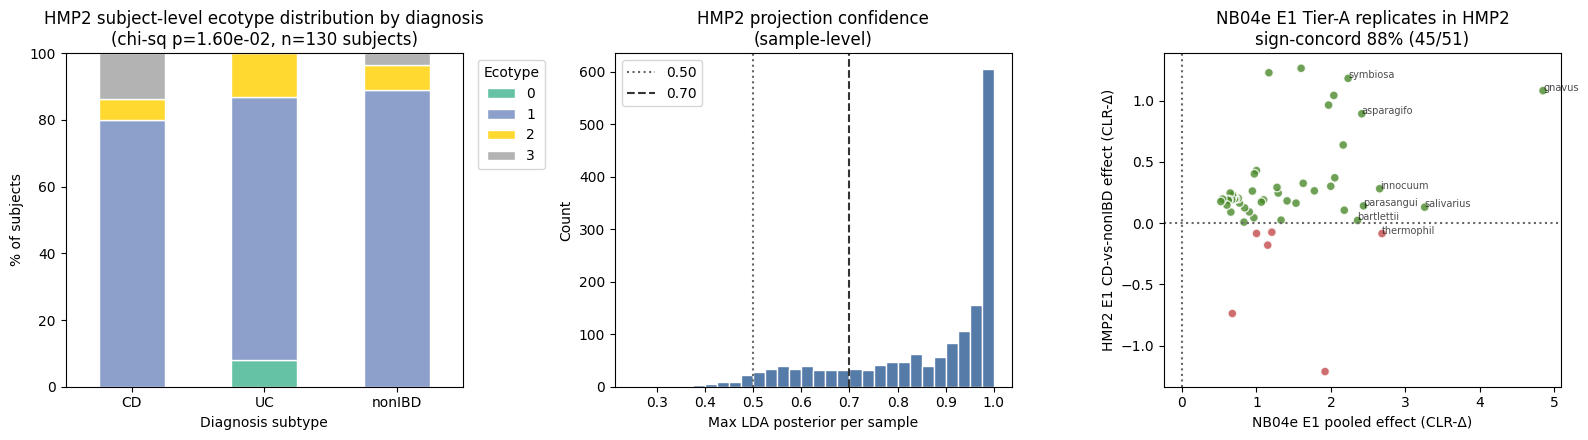

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) subject-level ecotype × diag_lab stacked bar
ct_norm = ct_subject.div(ct_subject.sum(axis=1), axis=0) * 100
ct_norm.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='white', legend=True)
axes[0].set_title(f'HMP2 subject-level ecotype distribution by diagnosis\n(chi-sq p={p:.2e}, n={len(subj)} subjects)')
axes[0].set_ylabel('% of subjects')
axes[0].set_xlabel('Diagnosis subtype')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Ecotype', bbox_to_anchor=(1.02, 1), loc='upper left')

# (b) projection confidence histogram
axes[1].hist(hmp2_max, bins=30, color='#557ba8', edgecolor='white')
axes[1].axvline(0.5, ls=':', color='#666', label='0.50')
axes[1].axvline(0.7, ls='--', color='#333', label='0.70')
axes[1].set_xlabel('Max LDA posterior per sample')
axes[1].set_ylabel('Count')
axes[1].set_title('HMP2 projection confidence\n(sample-level)')
axes[1].legend()

# (c) E1 Tier-A replication scatter (NB04e effect vs HMP2 E1 effect)
if len(cross):
    m = cross.dropna(subset=['hmp2_e1_effect'])
    colors_ = ['#4a8a2a' if c else '#c44a4a' for c in m.hmp2_concordant]
    axes[2].scatter(m.pooled_effect, m.hmp2_e1_effect, c=colors_, s=40, edgecolor='white', alpha=0.8)
    axes[2].axhline(0, ls=':', color='#666')
    axes[2].axvline(0, ls=':', color='#666')
    for _, r in m.head(8).iterrows():
        axes[2].annotate(r.species.split(' ')[-1][:10], (r.pooled_effect, r.hmp2_e1_effect), fontsize=7, alpha=0.7)
    axes[2].set_xlabel('NB04e E1 pooled effect (CLR-Δ)')
    axes[2].set_ylabel('HMP2 E1 CD-vs-nonIBD effect (CLR-Δ)')
    rep_rate = m.hmp2_concordant.mean() if len(m) else 0.0
    axes[2].set_title(f'NB04e E1 Tier-A replicates in HMP2\nsign-concord {rep_rate:.0%} ({m.hmp2_concordant.sum()}/{len(m)})')
else:
    axes[2].text(0.5, 0.5, 'E1 Tier-A replication skipped\n(insufficient HMP2 samples)',
                 ha='center', va='center', fontsize=12)
    axes[2].set_axis_off()

plt.tight_layout()
plt.savefig(FIG_OUT / 'NB04h_hmp2_external_replication.png', dpi=120, bbox_inches='tight')
plt.show()


## §7. Verdict artifact

In [8]:
replication_rate = float(cross.hmp2_concordant.mean()) if len(cross) else None
verdict_obj = {
    'date': '2026-04-24',
    'test': 'HMP_2019_ibdmdb (HMP2) external replication via curatedMetagenomicData v3.18',
    'n_hmp2_samples': int(len(hmp2_md)),
    'n_hmp2_subjects': int(len(subj)),
    'n_hmp2_species': int(hmp2_ab.shape[0]),
    'training_feature_overlap': int(len(set(hmp2_ab.index) & set(w.index))),
    'subject_level_chi2': {
        'statistic': round(float(chi2), 3),
        'dof': int(dof),
        'p_value': float(p),
        'contingency': ct_subject.to_dict(),
    },
    'projection_confidence': {
        'mean_max_posterior': round(float(hmp2_max.mean()), 3),
        'frac_below_0.50': round(float((hmp2_max < 0.50).mean()), 3),
        'frac_above_0.70': round(float((hmp2_max > 0.70).mean()), 3),
    },
    'e1_tier_a_replication_sign_concord': round(replication_rate, 3) if replication_rate is not None else None,
    'verdict': None,
}
if replication_rate is not None:
    if p < 0.05 and replication_rate >= 0.70:
        verdict_obj['verdict'] = 'PASS — HMP2 ecotype stratification significant AND E1 Tier-A >= 70% sign-concordant'
    elif p < 0.05 and replication_rate >= 0.50:
        verdict_obj['verdict'] = 'PARTIAL — HMP2 ecotype stratification significant; E1 Tier-A moderate concordance'
    elif p < 0.05:
        verdict_obj['verdict'] = 'ECOTYPE-ONLY — HMP2 ecotype distribution replicates, but E1 Tier-A replication is weak'
    else:
        verdict_obj['verdict'] = 'FAIL — HMP2 ecotype stratification is not significant'
else:
    verdict_obj['verdict'] = 'UNDEFINED — insufficient HMP2 samples to test E1 replication'

with open(DATA_OUT / 'nb04h_hmp2_replication_verdict.json', 'w') as f:
    json.dump(verdict_obj, f, indent=2)

print('Saved data/nb04h_hmp2_*.tsv + data/nb04h_hmp2_replication_verdict.json + figures/NB04h_hmp2_external_replication.png')
print()
print('=' * 70)
print('HMP2 EXTERNAL REPLICATION VERDICT')
print('=' * 70)
print(verdict_obj['verdict'])


Saved data/nb04h_hmp2_*.tsv + data/nb04h_hmp2_replication_verdict.json + figures/NB04h_hmp2_external_replication.png

HMP2 EXTERNAL REPLICATION VERDICT
PASS — HMP2 ecotype stratification significant AND E1 Tier-A >= 70% sign-concordant
